# 20 — Building a Small CNN

This notebook assembles the reusable convolution, ReLU, pooling, affine, and softmax operations into one image classifier:

```text
conv → ReLU → max pool → affine → ReLU → affine → softmax loss
```

The goal is not benchmark accuracy. It is to understand how spatial feature maps become class scores and how gradients travel back through the complete network.

## Learning objectives

- trace every activation and parameter shape;
- flatten pooled feature maps without mixing examples;
- assemble a complete forward pass from reusable layers;
- add softmax loss and L2 regularization;
- implement the complete backward pass in reverse order;
- numerically check every learned parameter;
- overfit a small synthetic image dataset as an integration test.

In [40]:
import matplotlib.pyplot as plt
import numpy as np

from cs231n_practice.cnn_layers import (
    conv_backward_naive,
    conv_forward_naive,
    convolution_output_shape,
    max_pool_backward_naive,
    max_pool_forward_naive,
    pooling_output_shape,
)
from cs231n_practice.gradient_check import eval_numerical_gradient, relative_error
from cs231n_practice.layers import (
    affine_backward,
    affine_forward,
    affine_relu_backward,
    affine_relu_forward,
    relu_backward,
    relu_forward,
    softmax_loss,
)

SEED = 42
np.set_printoptions(precision=4, suppress=True)

## 1. Architecture and shape flow

Use these symbols:

- $N$: examples; $C$: input channels; $H,W$: input height and width;
- $F$: convolution filters; $HH,WW$: filter height and width;
- $H_h$: hidden affine units; $K$: classes.

The parameter shapes are

$$
W_1:(F,C,HH,WW),\qquad b_1:(F),
$$

$$
W_2:(D_{flat},H_h),\qquad b_2:(H_h),
$$

$$
W_3:(H_h,K),\qquad b_3:(K).
$$

After pooling,

$$
D_{flat}=F H_{pool}W_{pool}.
$$

### Exercise 1 — Trace concrete shapes

For input `(N, 3, 8, 8)`, four $3\times3$ filters with padding 1 and stride 1, $2\times2$ pooling with stride 2, six hidden units, and three classes, complete the expected shapes.

In [41]:
N, C, H, W = 5, 3, 8, 8
F, HH, WW = 4, 3, 3
HIDDEN, NUM_CLASSES = 6, 3
conv_height, conv_width = convolution_output_shape(
    H, W, HH, WW, padding=1, stride=1
)
pool_height_out, pool_width_out = pooling_output_shape(
    conv_height, conv_width, 2, 2, stride=2
)
flat_dim = F * pool_height_out * pool_width_out

# fill in the seven expected shape tuples.
expected_shapes = {
    "W1": (F, C, HH, WW),
    "conv": (N, F, conv_height, conv_width),
    "pool": (N, F, pool_height_out, pool_width_out),
    "flat": (N, flat_dim),
    "W2": (flat_dim, HIDDEN),
    "W3": (HIDDEN, NUM_CLASSES),
    "scores": (N, NUM_CLASSES),
}
assert expected_shapes == {
    "W1": (4, 3, 3, 3),
    "conv": (5, 4, 8, 8),
    "pool": (5, 4, 4, 4),
    "flat": (5, 64),
    "W2": (64, 6),
    "W3": (6, 3),
    "scores": (5, 3),
}
expected_shapes

{'W1': (4, 3, 3, 3),
 'conv': (5, 4, 8, 8),
 'pool': (5, 4, 4, 4),
 'flat': (5, 64),
 'W2': (64, 6),
 'W3': (6, 3),
 'scores': (5, 3)}

## 2. Parameter initialization

We use small random weights and zero biases. A fan-in-scaled standard deviation gives each layer a scale related to the number of inputs feeding one unit:

$$
\text{scale}=\sqrt{\frac{2}{\text{fan-in}}}.
$$

For a convolutional filter, fan-in is $C\cdot HH\cdot WW$. For an affine layer, it is the first weight dimension.

### Exercise 2 — Initialize all parameters

Complete the initializer. It should infer the flattened dimension from the input and layer configuration rather than hard-code it.

In [42]:
def initialize_small_cnn(
    input_shape, num_filters, filter_size, hidden_dim, num_classes, *, seed
):
    """Initialize parameters for conv-ReLU-pool-affine-ReLU-affine."""
    input_channels, input_height, input_width = input_shape
    conv_height, conv_width = convolution_output_shape(
        input_height, input_width, filter_size, filter_size,
        padding=(filter_size - 1) // 2, stride=1,
    )
    pooled_height, pooled_width = pooling_output_shape(
        conv_height, conv_width, 2, 2, stride=2
    )
    flattened_dim = num_filters * pooled_height * pooled_width
    generator = np.random.default_rng(seed)

    # create W1, b1, W2, b2, W3, and b3.
    w1_scale = np.sqrt(
        2.0 / (input_channels * filter_size * filter_size)
    )
    w2_scale = np.sqrt(2.0 / flattened_dim)
    parameters = {
        "W1": generator.normal(0.0, size=(num_filters, input_channels, filter_size, filter_size), scale=w1_scale), # (F, C, HH, WW),
        "b1": np.zeros((num_filters,)),
        "W2": generator.normal(0.0, size=(flattened_dim, hidden_dim), scale=w2_scale), # (flat_dim, HIDDEN),
        "b2": np.zeros((hidden_dim,)),
        "W3": generator.normal(0.0, size=(hidden_dim, num_classes), scale=np.sqrt(2.0 / hidden_dim)), # (HIDDEN, NUM_CLASSES),
        "b3": np.zeros((num_classes,)),
    }
    return parameters


shape_parameters = initialize_small_cnn(
    (3, 8, 8), 4, 3, 6, 3, seed=SEED
)
assert {name: value.shape for name, value in shape_parameters.items()} == {
    "W1": (4, 3, 3, 3), "b1": (4,),
    "W2": (64, 6), "b2": (6,),
    "W3": (6, 3), "b3": (3,),
}
{name: value.shape for name, value in shape_parameters.items()}

{'W1': (4, 3, 3, 3),
 'b1': (4,),
 'W2': (64, 6),
 'b2': (6,),
 'W3': (6, 3),
 'b3': (3,)}

## 3. Complete forward pass

The pooled tensor has shape $(N,F,H_{pool},W_{pool})$. Flatten only the last three dimensions:

```python
flat = pooled.reshape(N, -1)
```

Keeping $N$ separate prevents examples from being mixed. During backward propagation, reshape `dflat` back to the exact pooled shape.

### Exercise 3 — Assemble inference

Complete the forward sequence. When `labels is None`, return class scores without calculating loss or gradients.

In [43]:
def small_cnn_loss(parameters, x, labels=None, *, regularization_strength=0.0):
    """Return scores, or loss and gradients for a small CNN."""
    conv, conv_cache = conv_forward_naive(
        x, parameters["W1"], parameters["b1"], stride=1, padding=1
    )
    # ReLU, 2x2 stride-2 max pooling, flatten, affine-ReLU, affine.
    activated, relu_cache = relu_forward(conv)
    pooled, pool_cache = max_pool_forward_naive(activated, pool_width=2, pool_height=2, stride=2)
    flat = pooled.reshape(x.shape[0], -1) # number of samples to flatten shapes
    hidden, hidden_cache = affine_relu_forward(flat,  parameters["W2"], parameters["b2"])
    scores, scores_cache = affine_forward(hidden,  parameters["W3"], parameters["b3"])

    if labels is None:
        return scores

    # Exercises 4 and 5 continue this training branch below.
    # Softmax loss.
    data_loss, dscores = softmax_loss(scores, labels)
    # Add regularization loss.
    weight_penalty = np.sum(parameters["W1"] ** 2) + np.sum(parameters["W2"] ** 2) + np.sum(parameters["W3"] ** 2)
    l2_loss = regularization_strength * weight_penalty
    loss = data_loss + l2_loss

    # backward (reverse) pass softma ← affine 3 ← affine-ReLU 2 ← reshape to pooled shape ← max pool ← ReLU ← convolution 1 
    dhidden, dW3, db3 = affine_backward(dscores, scores_cache)
    dflat, dW2, db2 = affine_relu_backward(dhidden, hidden_cache)
    dpooled = dflat.reshape(pooled.shape)
    dactivated = max_pool_backward_naive(dpooled, pool_cache)
    dconv = relu_backward(dactivated, relu_cache)
    _, dW1, db1 = conv_backward_naive(dconv, conv_cache)

    # add regularization gradient
    dW3 += regularization_strength*2*parameters["W3"]
    dW2 += regularization_strength*2*parameters["W2"]
    dW1 += regularization_strength*2*parameters["W1"]

    gradients = {"W1": dW1, "b1": db1, "W2": dW2, "b2": db2, "W3": dW3, "b3": db3}

    return loss, gradients

## 4. Loss and regularization

The objective combines mean softmax data loss with L2 penalties on all weight tensors:

$$
L=L_{data}+\lambda(\lVert W_1\rVert_2^2+\lVert W_2\rVert_2^2+\lVert W_3\rVert_2^2).
$$

Biases are not regularized. Under this project's no-$1/2$ convention, each regularization gradient is $2\lambda W$.

### Exercise 4 — Add training loss

Inside `small_cnn_loss`, calculate softmax loss and add L2 penalties for `W1`, `W2`, and `W3`. Keep the returned `dscores` for the backward pass.

## 5. Complete backward pass

Reverse the forward sequence:

```text
softmax
← affine 3
← affine-ReLU 2
← reshape to pooled shape
← max pool
← ReLU
← convolution 1
```

The reshape has no numerical derivative beyond rearranging entries, but its backward operation must restore the exact pre-flatten shape.

### Exercise 5 — Finish `small_cnn_loss`

Continue the function's training branch. Return a gradient dictionary with exactly the same keys and shapes as `parameters`, and add regularization only to weight gradients.

A compact outline for the missing training branch is:

```python
data_loss, dscores = softmax_loss(scores, labels)
# Add regularization loss.

dhidden, dW3, db3 = affine_backward(dscores, scores_cache)
dflat, dW2, db2 = affine_relu_backward(dhidden, hidden_cache)
dpooled = dflat.reshape(pooled.shape)
dactivated = max_pool_backward_naive(dpooled, pool_cache)
dconv = relu_backward(dactivated, relu_cache)
_, dW1, db1 = conv_backward_naive(dconv, conv_cache)
# Add regularization gradients and return.
```

Write this logic inside the function cell rather than executing the outline separately.

## 6. End-to-end gradient checking

Checking individual layers is necessary but does not verify their composition. A tiny complete network can catch wrong cache order, an incorrect reshape, omitted regularization, or gradients assigned to the wrong parameter key.

### Exercise 6 — Check every parameter

Use a tiny double-precision model. For each parameter, perturb only that array while holding the others fixed. ReLU and max pooling are nondifferentiable at boundaries, so errors may occasionally require a different random seed.

In [44]:
check_generator = np.random.default_rng(7)
check_x = check_generator.normal(size=(2, 2, 4, 4))
check_labels = np.array([0, 2])
check_parameters = initialize_small_cnn((2, 4, 4), 2, 3, 3, 3, seed=8)
check_regularization = 0.05
check_loss, analytical_gradients = small_cnn_loss(
    check_parameters, check_x, check_labels,
    regularization_strength=check_regularization,
)
gradient_errors = {}

for parameter_name, parameter_value in check_parameters.items():
    # construct a scalar function replacing only parameter_name.
    def loss_with_candidate(candidate):
        parameters_copy = check_parameters.copy()
        parameters_copy[parameter_name] = candidate
        return small_cnn_loss(
            parameters_copy,
            check_x,
            check_labels,
            regularization_strength=check_regularization,
        )[0]

    numerical_gradient = eval_numerical_gradient(
        loss_with_candidate, parameter_value
    )
    gradient_errors[parameter_name] = relative_error(
        analytical_gradients[parameter_name], numerical_gradient
    )

print("Loss:", check_loss)
print(gradient_errors)
assert set(analytical_gradients) == set(check_parameters)
assert all(
    analytical_gradients[name].shape == check_parameters[name].shape
    for name in check_parameters
)
assert all(error < 1e-6 for error in gradient_errors.values())

Loss: 2.236867703582928
{'W1': 1.8167295802632628e-10, 'b1': 2.3507808349327833e-11, 'W2': 3.430341461968037e-07, 'b2': 8.19694221387967e-11, 'W3': 1.7039880180929852e-09, 'b3': 4.803223500625532e-10}


## 7. Synthetic image classification

The dataset contains noisy $8\times8$ images with one of three spatial patterns: a vertical bar, a horizontal bar, or a diagonal. These classes are intentionally simple, but they test whether the assembled CNN can learn from spatial structure.

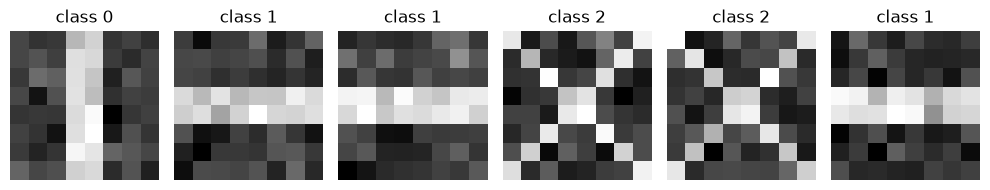

In [45]:
def make_pattern_dataset(*, examples_per_class, noise, seed):
    generator = np.random.default_rng(seed)
    images = []
    labels = []
    for label in range(3):
        for _ in range(examples_per_class):
            image = np.zeros((8, 8), dtype=np.float64)
            if label == 0:
                image[:, 3:5] = 1.0
            elif label == 1:
                image[3:5, :] = 1.0
            else:
                np.fill_diagonal(image, 1.0)
                np.fill_diagonal(np.fliplr(image), 1.0)
            image += generator.normal(scale=noise, size=image.shape)
            images.append(image[None, :, :])
            labels.append(label)
    images = np.stack(images)
    labels = np.asarray(labels, dtype=np.int64)
    order = generator.permutation(len(labels))
    return images[order], labels[order]


X_patterns, y_patterns = make_pattern_dataset(
    examples_per_class=12, noise=0.15, seed=SEED
)
fig, axes = plt.subplots(1, 6, figsize=(10, 2))
for axis, image, label in zip(axes, X_patterns[:6], y_patterns[:6]):
    axis.imshow(image[0], cmap="gray")
    axis.set_title(f"class {label}")
    axis.axis("off")
plt.tight_layout()
plt.show()

### Exercise 7 — Overfit the pattern dataset

Initialize a model with four filters and eight hidden units. Train with full-batch gradient descent for 200 iterations, learning rate `0.1`, and no regularization. Plot loss and report training accuracy.

Final loss: 0.0018521209078613428
Training accuracy: 1.0


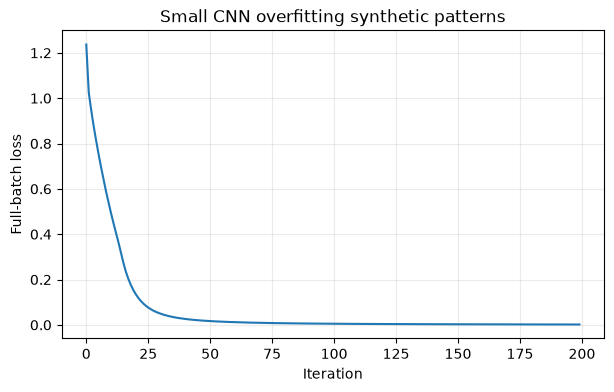

In [ ]:
pattern_parameters = initialize_small_cnn((1, 8, 8), 4, 3, 8, 3, seed=10)
loss_history = []

for iteration in range(200):
    # calculate loss and gradients, then update every parameter.
    loss, gradients = small_cnn_loss(pattern_parameters, X_patterns, y_patterns)

    for param_name in pattern_parameters.keys():
        pattern_parameters[param_name] -= 0.1 * gradients[param_name]

    loss_history.append(loss)


pattern_scores = small_cnn_loss(pattern_parameters, X_patterns)
pattern_predictions = np.argmax(pattern_scores, axis=1)
pattern_accuracy = np.mean(pattern_predictions == y_patterns)
print("Final loss:", loss_history[-1])
print("Training accuracy:", pattern_accuracy)
assert loss_history[-1] < loss_history[0]
assert pattern_accuracy > 0.95

plt.figure(figsize=(7, 4))
plt.plot(loss_history)
plt.xlabel("Iteration")
plt.ylabel("Full-batch loss")
plt.title("Small CNN overfitting synthetic patterns")
plt.grid(alpha=0.25)
plt.show()

## 8. Inspect learned feature maps

A feature map is not automatically a human-readable concept, but inspecting early activations can reveal which filters respond to particular edges or regions.

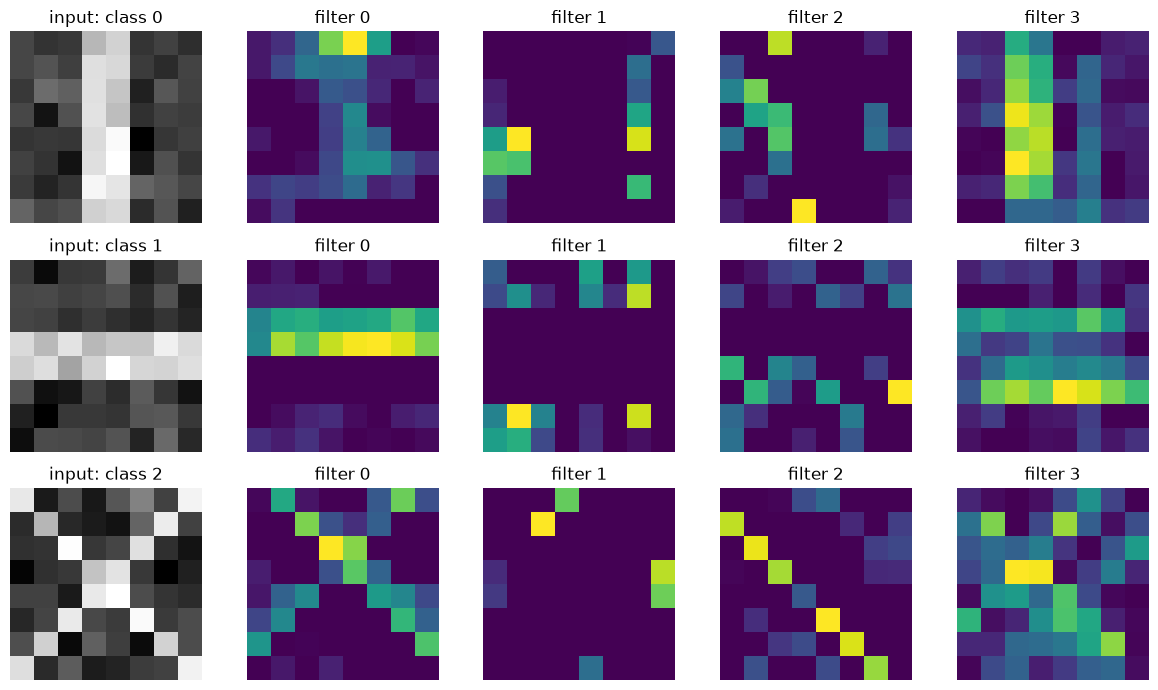

In [48]:
# Select one representative input from each class.
example_indices = [np.flatnonzero(y_patterns == label)[0] for label in range(3)]
example_images = X_patterns[example_indices]
example_conv, _ = conv_forward_naive(
    example_images, pattern_parameters["W1"], pattern_parameters["b1"],
    stride=1, padding=1,
)
example_activated, _ = relu_forward(example_conv)

fig, axes = plt.subplots(3, 5, figsize=(12, 7))
for row, (example_index, label) in enumerate(zip(example_indices, range(3))):
    axes[row, 0].imshow(X_patterns[example_index, 0], cmap="gray")
    axes[row, 0].set_title(f"input: class {label}")
    for filter_index in range(4):
        axes[row, filter_index + 1].imshow(
            example_activated[row, filter_index], cmap="viridis"
        )
        axes[row, filter_index + 1].set_title(f"filter {filter_index}")
for axis in axes.ravel():
    axis.axis("off")
plt.tight_layout()
plt.show()

## Reflection

Add a Markdown cell answering:

1. Why does the network flatten only after convolution and pooling?
2. Why must the batch dimension remain separate during flattening?
3. What determines the first affine layer's input dimension?
4. Why is the backward sequence the reverse of the forward sequence?
5. What does reshaping `dflat` back to `pooled.shape` accomplish?
6. Why are only weight tensors regularized?
7. Why does each regularization gradient contain $2\lambda W$ here?
8. What additional bugs can an end-to-end gradient check catch?
9. What does successful overfitting of the pattern dataset demonstrate?
10. What does it not demonstrate about generalization?
11. Why are the learned feature maps difficult to name precisely?
12. What is the main limitation of this synthetic experiment?

After this notebook is complete, the verified network can be extracted into `cs231n_practice/classifiers/cnn.py`. Batch normalization and dropout will be studied after establishing this baseline CNN.

1. Convolution and pooling need the channel, height, and width structure to learn and summarize local spatial patterns. Flattening is delayed until those spatial features have been extracted.
2. The batch dimension identifies separate images. Keeping it separate prevents features from different examples from being mixed into one vector.
3. The first affine input dimension is $F H_{pool}W_{pool}$: the number of filters multiplied by the pooled height and width.
4. The chain rule requires each layer's upstream gradient, so backpropagation follows the dependencies in reverse forward order.
5. It restores the spatial layout expected by max-pooling backward while preserving the same gradient values.
6. Weights control multiplicative feature strength and model complexity. Biases only shift activations, so penalizing them is usually unnecessary in this convention.
7. The penalty is $\lambda\sum W^2$, and the derivative of $W^2$ is $2W$, giving $2\lambda W$.
8. It can catch incorrect cache order, wrong reshaping, missing regularization gradients, and gradients assigned to the wrong parameter.
9. Successful overfitting shows that the assembled forward pass, backward pass, optimizer, and model capacity can fit this small dataset.
10. It does not show that the network will classify unseen or more varied images correctly.
11. A filter may respond to several related local patterns, and its meaning depends on the input and later layers rather than one named concept.
12. The dataset is tiny, artificial, and evaluated on its training examples, so it does not represent realistic image-classification difficulty.